# MIND Small EDA

This notebook performs EDA on MIND small (train) and compares train vs dev.

In [2]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NEWS_COLUMNS = [
    'news_id',
    'category',
    'subcategory',
    'title',
    'abstract',
    'url',
    'title_entities',
    'abstract_entities',
]

BEH_COLUMNS = ['impression_id', 'user_id', 'time', 'history', 'impressions']

def _split_len(s):
    if not isinstance(s, str) or not s:
        return 0
    return len(s.split())

def _safe_json_len(s):
    if not isinstance(s, str) or not s:
        return 0
    if s == '[]' or s.lower() == 'null':
        return 0
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return len(val)
        return 0
    except json.JSONDecodeError:
        return 0

def _gini(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return float('nan')
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cum = np.cumsum(x)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
    return float(gini)

def _top_share(counts, pct):
    if counts.size == 0:
        return float('nan')
    k = max(1, int(math.ceil(counts.size * pct)))
    return float(np.sort(counts)[-k:].sum() / counts.sum())


## Paths

In [3]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

train_dir = project_root / 'data' / 'MINDsmall_train'
dev_dir = project_root / 'data' / 'MINDsmall_dev'


## Load train split

In [4]:
news = pd.read_csv(train_dir / 'news.tsv', sep='\t', header=None, names=NEWS_COLUMNS)
behaviors = pd.read_csv(train_dir / 'behaviors.tsv', sep='\t', header=None, names=BEH_COLUMNS)

behaviors['time'] = pd.to_datetime(behaviors['time'], errors='coerce')
behaviors['history_len'] = behaviors['history'].apply(_split_len)
behaviors['impr_len'] = behaviors['impressions'].apply(_split_len)
behaviors['clicks_in_impr'] = behaviors['impressions'].apply(
    lambda s: sum(1 for x in s.split() if x.endswith('-1')) if isinstance(s, str) else 0
)

news['title_len'] = news['title'].apply(_split_len)
news['abstract_len'] = news['abstract'].apply(_split_len)
news['title_ent_len'] = news['title_entities'].apply(_safe_json_len)
news['abstract_ent_len'] = news['abstract_entities'].apply(_safe_json_len)

impr = behaviors[['user_id', 'time', 'impressions']].copy()
impr['impressions'] = impr['impressions'].str.split(' ')
impr = impr.explode('impressions')
impr = impr.dropna(subset=['impressions'])
split = impr['impressions'].str.rsplit('-', n=1, expand=True)
impr['news_id'] = split[0]
impr['clicked'] = split[1].astype(int)

clicks = impr[impr['clicked'] == 1]
click_counts = clicks['news_id'].value_counts()

user_agg = behaviors.groupby('user_id').agg(
    sessions=('impression_id', 'count'),
    impressions=('impr_len', 'sum'),
    clicks=('clicks_in_impr', 'sum'),
    history_mean=('history_len', 'mean'),
)
user_agg['ctr'] = user_agg['clicks'] / user_agg['impressions'].replace(0, np.nan)

cat_map = news.set_index('news_id')['category'].to_dict()
impr['category'] = impr['news_id'].map(cat_map)
cat_stats = impr.groupby('category').agg(
    impressions=('clicked', 'count'),
    clicks=('clicked', 'sum'),
)
cat_stats['ctr'] = cat_stats['clicks'] / cat_stats['impressions'].replace(0, np.nan)
cat_stats = cat_stats.sort_values('clicks', ascending=False)

subcat_map = news.set_index('news_id')['subcategory'].to_dict()
impr['subcategory'] = impr['news_id'].map(subcat_map)
subcat_stats = impr.groupby('subcategory').agg(
    impressions=('clicked', 'count'),
    clicks=('clicked', 'sum'),
)
subcat_stats['ctr'] = subcat_stats['clicks'] / subcat_stats['impressions'].replace(0, np.nan)
subcat_stats = subcat_stats.sort_values('clicks', ascending=False)

user_item_space = int(behaviors['user_id'].nunique() * news['news_id'].nunique())
summary = {
    'num_users': int(behaviors['user_id'].nunique()),
    'num_sessions': int(behaviors.shape[0]),
    'num_articles': int(news['news_id'].nunique()),
    'num_impressions': int(impr.shape[0]),
    'num_clicks': int(clicks.shape[0]),
    'overall_ctr': float(clicks.shape[0] / max(1, impr.shape[0])),
    'avg_impressions_per_session': float(behaviors['impr_len'].mean()),
    'avg_clicks_per_session': float(behaviors['clicks_in_impr'].mean()),
    'avg_history_len': float(behaviors['history_len'].mean()),
    'num_categories': int(news['category'].nunique()),
    'num_subcategories': int(news['subcategory'].nunique()),
    'articles_with_clicks': int(click_counts.size),
    'articles_without_clicks': int(news['news_id'].nunique() - click_counts.size),
    'gini_clicks': _gini(click_counts.values),
    'top_1pct_click_share': _top_share(click_counts.values, 0.01),
    'top_5pct_click_share': _top_share(click_counts.values, 0.05),
    'top_10pct_click_share': _top_share(click_counts.values, 0.10),
    'sparsity_clicks': float(clicks.shape[0] / max(1, user_item_space)),
    'user_item_space': int(user_item_space),
}
pd.DataFrame([summary])


,num_users,num_sessions,num_articles,num_impressions,num_clicks,overall_ctr,avg_impressions_per_session,avg_clicks_per_session,avg_history_len,num_categories,num_subcategories,articles_with_clicks,articles_without_clicks,gini_clicks,top_1pct_click_share,top_5pct_click_share,top_10pct_click_share,sparsity_clicks,user_item_space
0,50000,156965,51282,5843444,236344,0.040446,37.227688,1.505711,32.539987,17,264,7713,43569,0.852952,0.347379,0.644133,0.782326,0.000092,2564100000


## Distributions and plots

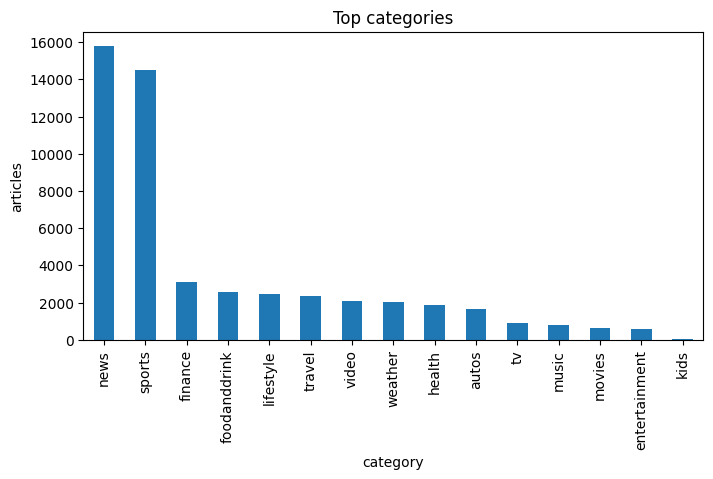

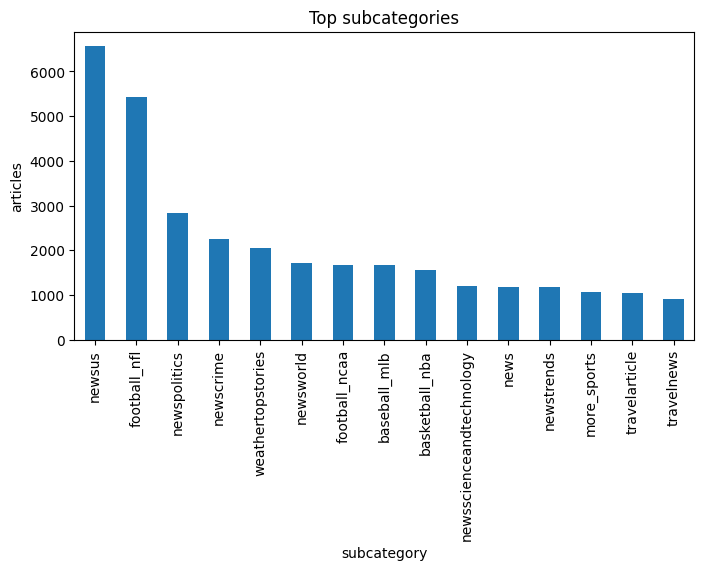

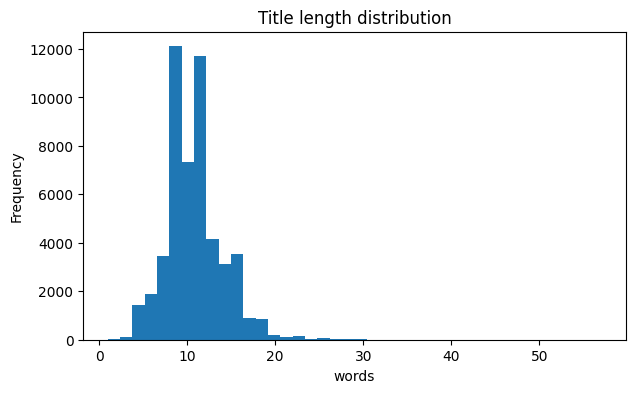

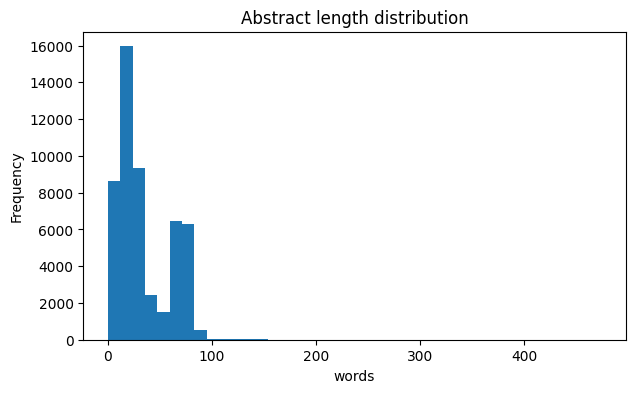

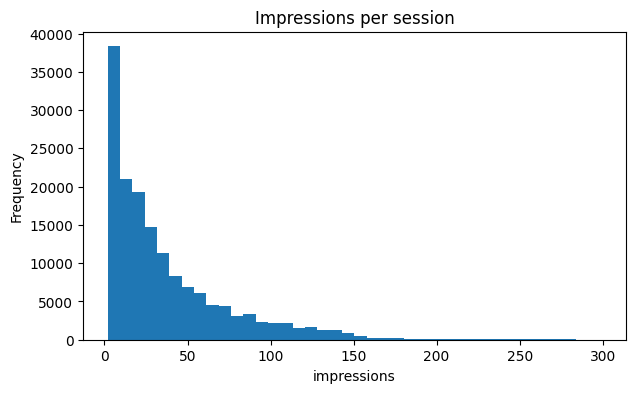

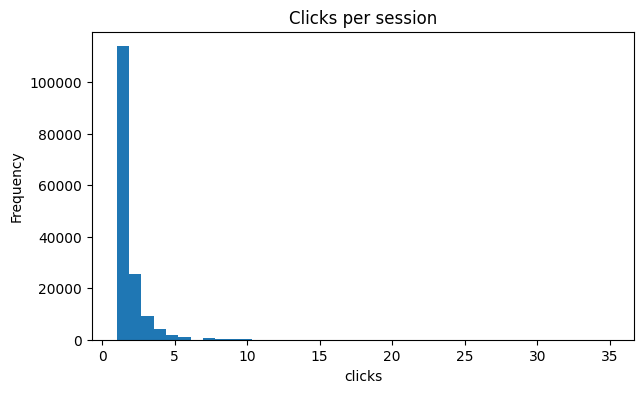

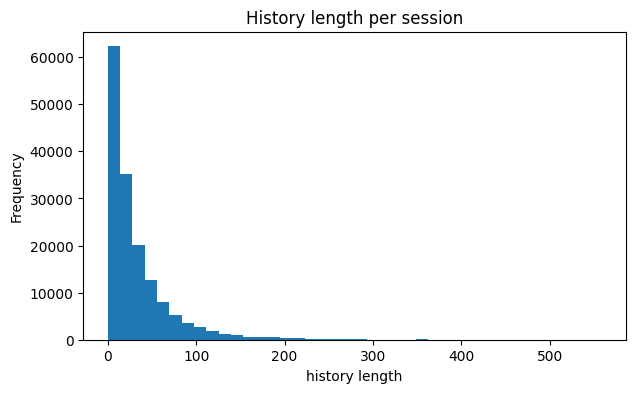

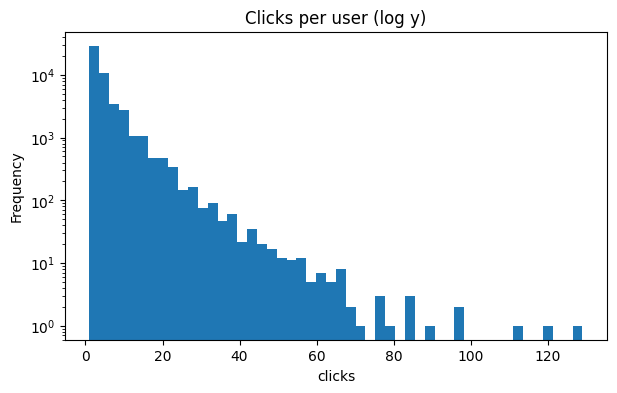

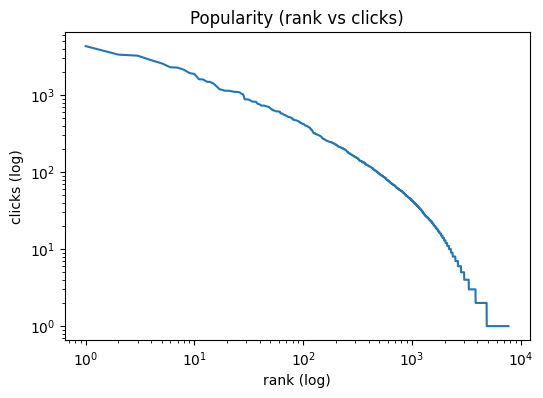

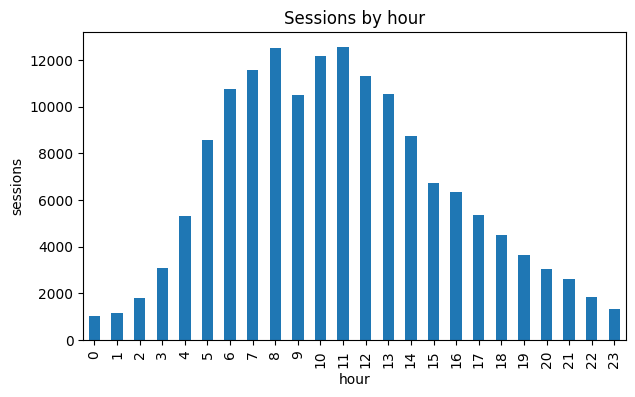

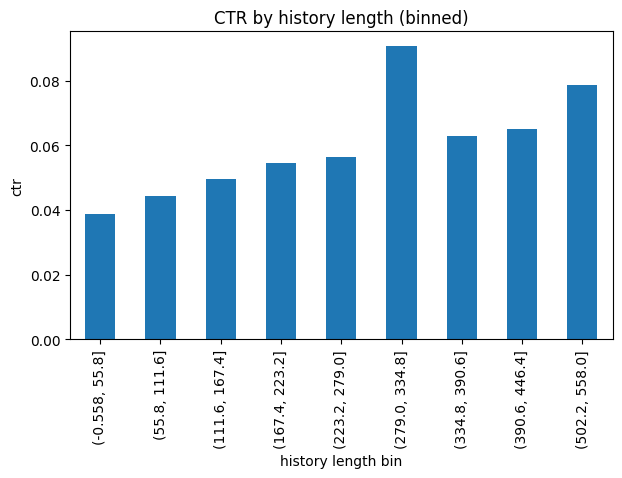

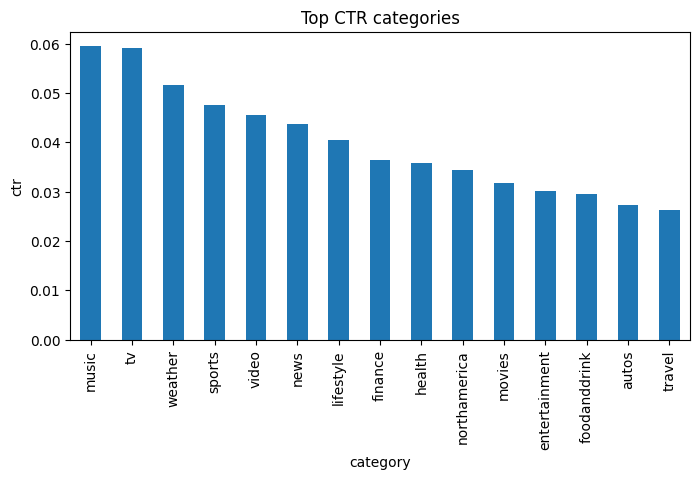

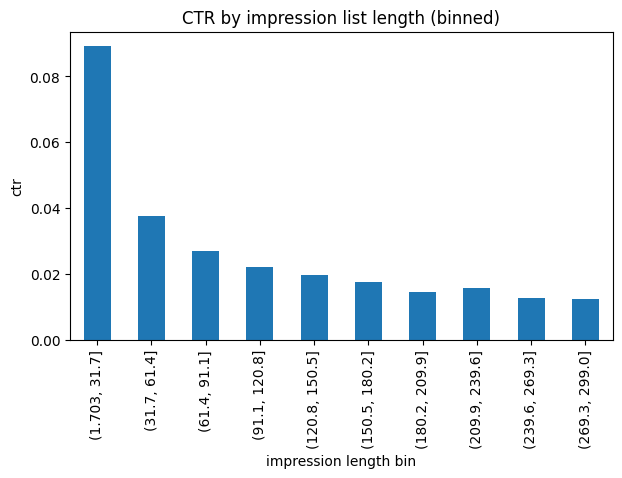

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
news['category'].value_counts().head(15).plot(kind='bar', ax=ax)
ax.set_title('Top categories')
ax.set_xlabel('category')
ax.set_ylabel('articles')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
news['subcategory'].value_counts().head(15).plot(kind='bar', ax=ax)
ax.set_title('Top subcategories')
ax.set_xlabel('subcategory')
ax.set_ylabel('articles')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
news['title_len'].plot(kind='hist', bins=40, ax=ax)
ax.set_title('Title length distribution')
ax.set_xlabel('words')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
news['abstract_len'].plot(kind='hist', bins=40, ax=ax)
ax.set_title('Abstract length distribution')
ax.set_xlabel('words')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
behaviors['impr_len'].plot(kind='hist', bins=40, ax=ax)
ax.set_title('Impressions per session')
ax.set_xlabel('impressions')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
behaviors['clicks_in_impr'].plot(kind='hist', bins=40, ax=ax)
ax.set_title('Clicks per session')
ax.set_xlabel('clicks')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
behaviors['history_len'].plot(kind='hist', bins=40, ax=ax)
ax.set_title('History length per session')
ax.set_xlabel('history length')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
user_agg['clicks'].plot(kind='hist', bins=50, ax=ax, logy=True)
ax.set_title('Clicks per user (log y)')
ax.set_xlabel('clicks')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sorted_clicks = np.sort(click_counts.values)[::-1]
ax.plot(np.arange(1, sorted_clicks.size + 1), sorted_clicks)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Popularity (rank vs clicks)')
ax.set_xlabel('rank (log)')
ax.set_ylabel('clicks (log)')
plt.show()

if behaviors['time'].notna().any():
    fig, ax = plt.subplots(figsize=(7, 4))
    behaviors['time'].dt.hour.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title('Sessions by hour')
    ax.set_xlabel('hour')
    ax.set_ylabel('sessions')
    plt.show()

hist_bins = pd.cut(behaviors['history_len'], bins=10)
hist_ctr = behaviors.groupby(hist_bins).apply(
    lambda d: d['clicks_in_impr'].sum() / max(1, d['impr_len'].sum())
)
fig, ax = plt.subplots(figsize=(7, 4))
hist_ctr.plot(kind='bar', ax=ax)
ax.set_title('CTR by history length (binned)')
ax.set_xlabel('history length bin')
ax.set_ylabel('ctr')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
cat_stats.sort_values('ctr', ascending=False).head(15)['ctr'].plot(kind='bar', ax=ax)
ax.set_title('Top CTR categories')
ax.set_xlabel('category')
ax.set_ylabel('ctr')
plt.show()

impr_len_bins = pd.cut(behaviors['impr_len'], bins=10)
ctr_by_impr_len = behaviors.groupby(impr_len_bins).apply(
    lambda d: d['clicks_in_impr'].sum() / max(1, d['impr_len'].sum())
)
fig, ax = plt.subplots(figsize=(7, 4))
ctr_by_impr_len.plot(kind='bar', ax=ax)
ax.set_title('CTR by impression list length (binned)')
ax.set_xlabel('impression length bin')
ax.set_ylabel('ctr')
plt.show()


## Cold-start analysis (train)

In [6]:
user_sessions = behaviors.groupby('user_id')['impression_id'].count()
user_clicks = behaviors.groupby('user_id')['clicks_in_impr'].sum()
cold_users_1_session = (user_sessions == 1).mean()
cold_users_0_clicks = (user_clicks == 0).mean()

article_clicks = impr[impr['clicked'] == 1]['news_id'].value_counts()
all_articles = news['news_id'].nunique()
cold_articles_0_clicks = 1.0 - (article_clicks.size / max(1, all_articles))

pd.DataFrame([{
    'pct_users_1_session': float(cold_users_1_session),
    'pct_users_0_clicks': float(cold_users_0_clicks),
    'pct_articles_0_clicks': float(cold_articles_0_clicks),
}])


,pct_users_1_session,pct_users_0_clicks,pct_articles_0_clicks
0,0.32766,0.0,0.849596


## Long-tail and label balance (train)

In [10]:
click_counts = impr[impr['clicked'] == 1]['news_id'].value_counts()
num_articles = news['news_id'].nunique()

long_tail = {
    'pct_articles_with_1_click': float((click_counts == 1).sum() / max(1, num_articles)),
    'pct_articles_with_2plus_clicks': float((click_counts >= 2).sum() / max(1, num_articles)),
    'pct_articles_with_5plus_clicks': float((click_counts >= 5).sum() / max(1, num_articles)),
}
pd.DataFrame([long_tail])


,pct_articles_with_1_click,pct_articles_with_2plus_clicks,pct_articles_with_5plus_clicks
0,0.055653,0.094751,0.058832


In [11]:
label_counts = impr['clicked'].value_counts(normalize=True).rename({0: 'neg', 1: 'pos'})
label_counts

clicked
neg    0.959554
pos    0.040446
Name: proportion, dtype: float64

## Data quality checks (train)

In [8]:
quality = {}

quality['news_rows'] = int(len(news))
quality['news_unique_ids'] = int(news['news_id'].nunique())
quality['news_duplicate_ids'] = int(len(news) - news['news_id'].nunique())

for col in ['title', 'category', 'subcategory', 'url']:
    missing = news[col].isna().sum()
    empty = (news[col].astype(str).str.len() == 0).sum()
    quality[f'news_missing_{col}'] = int(missing)
    quality[f'news_empty_{col}'] = int(empty)

quality['behaviors_rows'] = int(len(behaviors))
quality['behaviors_unique_impressions'] = int(behaviors['impression_id'].nunique())
quality['behaviors_duplicate_impressions'] = int(len(behaviors) - behaviors['impression_id'].nunique())
quality['behaviors_time_parse_rate'] = float(behaviors['time'].notna().mean())

impr_str = behaviors['impressions'].fillna('')
quality['behaviors_empty_impressions'] = int((impr_str.str.len() == 0).sum())
quality['behaviors_impressions_missing_label'] = int((~impr_str.str.contains(r'-[01]')).sum())

pd.DataFrame([quality])


,news_rows,news_unique_ids,news_duplicate_ids,news_missing_title,news_empty_title,news_missing_category,news_empty_category,news_missing_subcategory,news_empty_subcategory,news_missing_url,news_empty_url,behaviors_rows,behaviors_unique_impressions,behaviors_duplicate_impressions,behaviors_time_parse_rate,behaviors_empty_impressions,behaviors_impressions_missing_label
0,51282,51282,0,0,0,0,0,0,0,0,0,156965,156965,0,1.0,0,0


## Train vs dev comparison

In [15]:
dev_news = pd.read_csv(dev_dir / 'news.tsv', sep='\t', header=None, names=NEWS_COLUMNS)
dev_beh = pd.read_csv(dev_dir / 'behaviors.tsv', sep='\t', header=None, names=BEH_COLUMNS)

dev_beh['time'] = pd.to_datetime(dev_beh['time'], errors='coerce')
dev_beh['history_len'] = dev_beh['history'].apply(_split_len)
dev_beh['impr_len'] = dev_beh['impressions'].apply(_split_len)
dev_beh['clicks_in_impr'] = dev_beh['impressions'].apply(
    lambda s: sum(1 for x in s.split() if x.endswith('-1')) if isinstance(s, str) else 0
)

dev_impr = dev_beh[['user_id', 'time', 'impressions']].copy()
dev_impr['impressions'] = dev_impr['impressions'].str.split(' ')
dev_impr = dev_impr.explode('impressions')
dev_impr = dev_impr.dropna(subset=['impressions'])
split = dev_impr['impressions'].str.rsplit('-', n=1, expand=True)
dev_impr['news_id'] = split[0]
dev_impr['clicked'] = split[1].astype(int)

def summarize_split(news_df, beh_df, impr_df):
    clicks_df = impr_df[impr_df['clicked'] == 1]
    click_counts_df = clicks_df['news_id'].value_counts()
    user_item_space_df = int(beh_df['user_id'].nunique() * news_df['news_id'].nunique())
    return {
        'num_users': int(beh_df['user_id'].nunique()),
        'num_sessions': int(beh_df.shape[0]),
        'num_articles': int(news_df['news_id'].nunique()),
        'num_impressions': int(impr_df.shape[0]),
        'num_clicks': int(clicks_df.shape[0]),
        'overall_ctr': float(clicks_df.shape[0] / max(1, impr_df.shape[0])),
        'avg_impressions_per_session': float(beh_df['impr_len'].mean()),
        'avg_clicks_per_session': float(beh_df['clicks_in_impr'].mean()),
        'avg_history_len': float(beh_df['history_len'].mean()),
        'num_categories': int(news_df['category'].nunique()),
        'num_subcategories': int(news_df['subcategory'].nunique()),
        'articles_with_clicks': int(click_counts_df.size),
        'articles_without_clicks': int(news_df['news_id'].nunique() - click_counts_df.size),
        'gini_clicks': _gini(click_counts_df.values),
        'top_1pct_click_share': _top_share(click_counts_df.values, 0.01),
        'top_5pct_click_share': _top_share(click_counts_df.values, 0.05),
        'top_10pct_click_share': _top_share(click_counts_df.values, 0.10),
        'sparsity_clicks': float(clicks_df.shape[0] / max(1, user_item_space_df)),
        'user_item_space': int(user_item_space_df),
    }

train_summary = summary
dev_summary = summarize_split(dev_news, dev_beh, dev_impr)
summary_df = pd.DataFrame([train_summary, dev_summary], index=['train', 'dev'])
summary_df


,num_users,num_sessions,num_articles,num_impressions,num_clicks,overall_ctr,avg_impressions_per_session,avg_clicks_per_session,avg_history_len,num_categories,num_subcategories,articles_with_clicks,articles_without_clicks,gini_clicks,top_1pct_click_share,top_5pct_click_share,top_10pct_click_share,sparsity_clicks,user_item_space
train,50000,156965,51282,5843444,236344,0.040446,37.227688,1.505711,32.539987,17,264,7713,43569,0.852952,0.347379,0.644133,0.782326,0.000092,2564100000
dev,50000,73152,42416,2740998,111383,0.040636,37.469898,1.522624,32.295959,17,257,2212,40204,0.895281,0.456757,0.744907,0.858497,0.000053,2120800000


In [14]:
delta = (summary_df.loc['dev'] - summary_df.loc['train']).to_frame(name='dev_minus_train')
delta

,dev_minus_train
num_users,0.000000e+00
num_sessions,-8.381300e+04
num_articles,-8.866000e+03
num_impressions,-3.102446e+06
num_clicks,-1.249610e+05
overall_ctr,1.899180e-04
avg_impressions_per_session,2.422106e-01
avg_clicks_per_session,1.691266e-02
avg_history_len,-2.440275e-01
num_categories,0.000000e+00


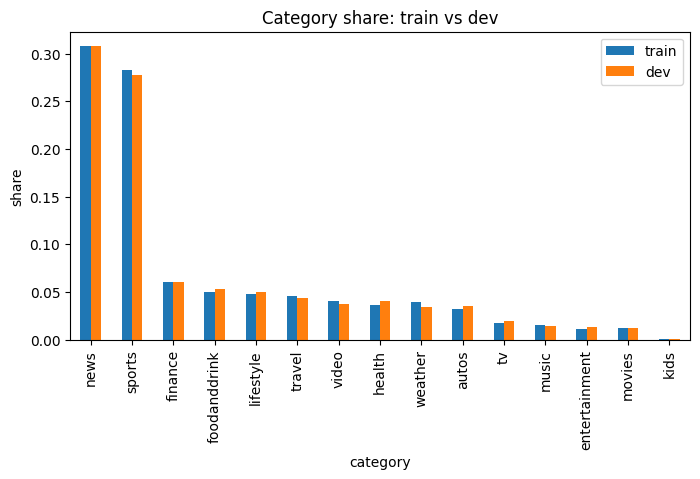

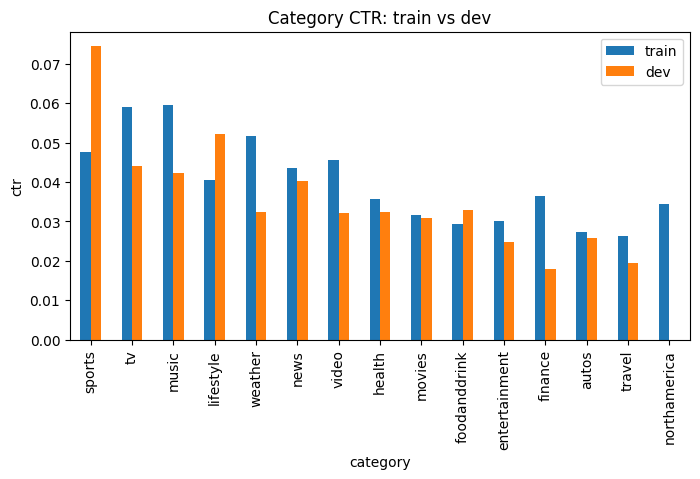

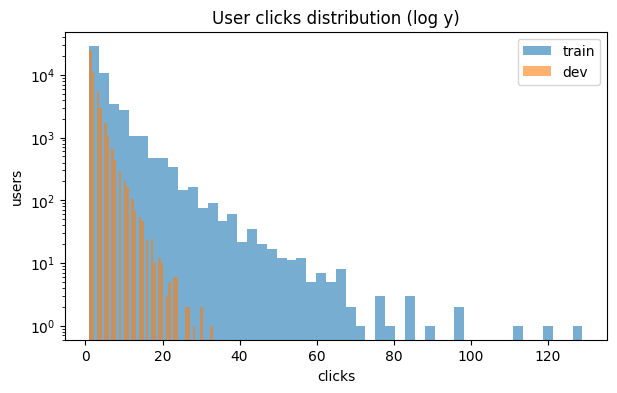

In [13]:
train_cat = news['category'].value_counts(normalize=True)
dev_cat = dev_news['category'].value_counts(normalize=True)
cat_comp = pd.concat([train_cat, dev_cat], axis=1, keys=['train', 'dev']).fillna(0)

top_cats = cat_comp.sum(axis=1).sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(8, 4))
cat_comp.loc[top_cats].plot(kind='bar', ax=ax)
ax.set_title('Category share: train vs dev')
ax.set_xlabel('category')
ax.set_ylabel('share')
plt.show()

def cat_ctr(impr_df, news_df):
    cat_map = news_df.set_index('news_id')['category'].to_dict()
    tmp = impr_df.copy()
    tmp['category'] = tmp['news_id'].map(cat_map)
    stats = tmp.groupby('category').agg(
        impressions=('clicked', 'count'),
        clicks=('clicked', 'sum'),
    )
    stats['ctr'] = stats['clicks'] / stats['impressions'].replace(0, np.nan)
    return stats['ctr']

train_ctr = cat_ctr(impr, news)
dev_ctr = cat_ctr(dev_impr, dev_news)
ctr_comp = pd.concat([train_ctr, dev_ctr], axis=1, keys=['train', 'dev']).fillna(0)

top_ctr_cats = ctr_comp.mean(axis=1).sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(8, 4))
ctr_comp.loc[top_ctr_cats].plot(kind='bar', ax=ax)
ax.set_title('Category CTR: train vs dev')
ax.set_xlabel('category')
ax.set_ylabel('ctr')
plt.show()

train_user_clicks = behaviors.groupby('user_id')['clicks_in_impr'].sum()
dev_user_clicks = dev_beh.groupby('user_id')['clicks_in_impr'].sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_user_clicks, bins=50, alpha=0.6, label='train')
ax.hist(dev_user_clicks, bins=50, alpha=0.6, label='dev')
ax.set_yscale('log')
ax.set_title('User clicks distribution (log y)')
ax.set_xlabel('clicks')
ax.set_ylabel('users')
ax.legend()
plt.show()